# Trying new set up with old case

In [1]:
from src.utils import *

In [17]:
from opendrift.models.openberg import OpenBerg
from opendrift.readers.reader_netCDF_CF_generic import Reader

o = OpenBerg(loglevel=50) #10-debug mode, 20, 50-overview info

# CONFIG
config_dict = {'drift:current_drag':True, 'seed:wind_form_drag_coef':1.5, 'seed:wind_form_drag_coef':1.5}
for ck in config_dict.keys(): o.set_config(ck,config_dict[ck])

# READERS
reader_wind = Reader('../input/era5_2023_09_10-18.nc',standard_name_mapping={'u10':'x_wind','v10':'y_wind'},name='ERA5-Reader')
o.add_reader(reader_wind)
o.add_readers_from_list(['cmems_mod_arc_phy_anfc_6km_detided_PT1H-i',])

# SEEDING
n=1
randspace=np.random.rand(n)
#lengths, widths = randspace*(87-75)+75, randspace**(80-65)+65
#sail, draft = 2.9914802407484546, 21.199466273020537 #not sure if correct
lengths, widths, sails, drafts = 81, 72, 2.9914802407484546, 21.199466273020537
lat, lon = 80.5794, 37.81915
icebergs = {'lon': lon, 'lat': lat,
            'length': lengths, 'width': widths, 
            'sail': sails, 'draft': drafts, 
            'number': n, 'radius': 100,
           'time': datetime(2023,9,10,12,36)}
o.seed_elements(**icebergs)

#RUN SIMULATIONS 
simulation_days = 2#8
o1 = o.run(duration=timedelta(days=simulation_days))
#that way o.plot, but o1 returns xarray.Dataset

Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 29.37it/s]
INFO - 2026-04-21T12:47:39Z - Selected dataset version: "202311"
INFO - 2026-04-21T12:47:39Z - Selected dataset part: "default"


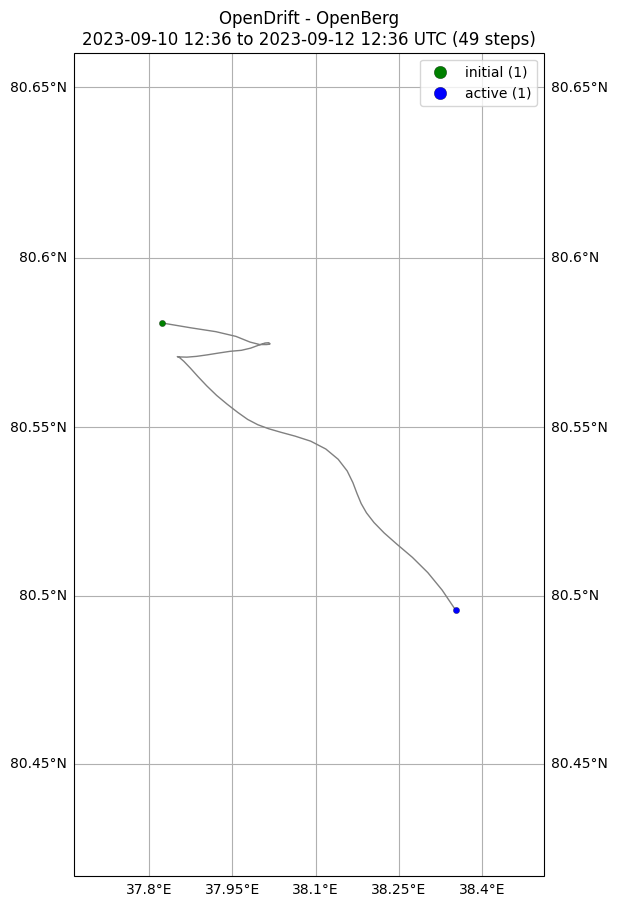

(<GeoAxes: title={'center': 'OpenDrift - OpenBerg\n2023-09-10 12:36 to 2023-09-12 12:36 UTC (49 steps)'}>,
 <Figure size 627.844x1100 with 1 Axes>)

In [19]:
# ANALYSIS
o.plot(fast=True)

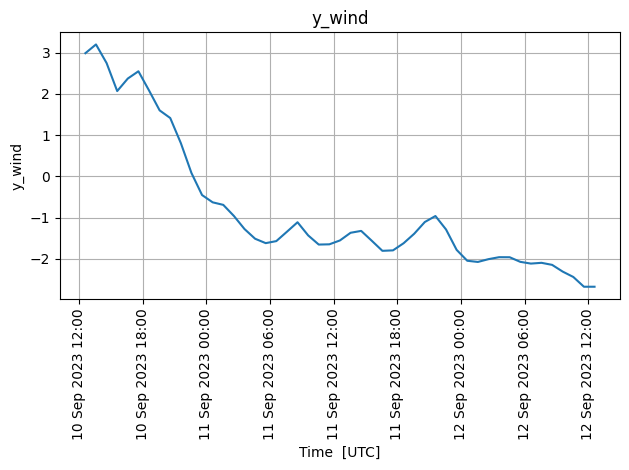

In [20]:
o.plot_property('y_wind')

In [ ]:
#o.animation(fast=True,filename='./simulation.gif',background=['sea_water_temperature','sea_water_temperature'],show_trajectories=True)#,color='z', buffer=.1
#Image(url='./simulation.gif')



In [ ]:
#SAVE TO NETCDF -> still has sttr dtype error
#ds=o1
#for k, v in ds.attrs.items():
#    if isinstance(v, np.generic):  # catches numpy scalars like np.int32, np.float64
#        ds.attrs[k] = v.item()     # convert to native Python type
#    elif isinstance(v, type) and issubclass(v, np.generic):
#        # handles cases like: np.int32 (the type itself)
#        ds.attrs[k] = v.__name__   # convert to string like "int32"
#    print(k, type(ds.attrs[k]))
#ds.to_netcdf("./results.nc") #not sure why not work no dri or file

#SAVE TO BINARY, #WORKS!
#import pickle 
#pickle.dump(o1,open("../results/results.bin",'wb'))

Fixed PROBLEMS:

- seeding does not get ib size -> works now
- does not read era5  --> needs name mapping

-> some kind of directiony probelm --> directionary error is gone

REMAINING PROBLEMS:
- does not save netcdf -> sttrb dtype error (but bin works)
